# PRT541 Assignment 1: FIFA World Cup 2026

### 2. Shooting

Do players from teams that reached the knockout stage have a significantly higher average number of shots on target per 90 minutes than players from teams eliminated in the group stage?

#### Load Data

In [7]:
shooting_df = pd.read_excel("World cup Shots.xlsx")
stages_df = pd.read_excel("World_Cup_2026_Team_Stages.xlsx")

In [9]:
print("SHOOTING DATASET")
print("Shape:", shooting_df.shape)
shooting_df.head()

SHOOTING DATASET
Shape: (1039, 4)


,Player,Pos,Country,SoT/90
0,Kylian Mbappé,FW,France,2.98
1,Lionel Messi,FW,Argentina,2.19
2,Jude Bellingham,MF,England,1.91
3,Erling Haaland,FW,Norway,2.52
4,Harry Kane,FW,England,1.66


In [11]:
print("TEAM STAGE DATASET")
print("Shape:", stages_df.shape)
stages_df.head()

TEAM STAGE DATASET
Shape: (48, 4)


,Country,Final Rank,Stage Reached,Analysis Group
0,Algeria,30,Round of 32,Knockout Stage
1,Argentina,2,Runner-up (Final),Knockout Stage
2,Australia,22,Round of 32,Knockout Stage
3,Austria,28,Round of 32,Knockout Stage
4,Belgium,6,Quarter-finals,Knockout Stage


In [13]:
print("\nNumber of unique countries in shooting data:", shooting_df["Country"].nunique())
print("Number of countries in stage data:", stages_df["Country"].nunique())


Number of unique countries in shooting data: 48
Number of countries in stage data: 48


In [23]:
# Merge the two datasets
df = shooting_df.merge(stages_df[["Country", "Analysis Group"]], on="Country", how="left")
df.head()

,Player,Pos,Country,SoT/90,Analysis Group
0,Kylian Mbappé,FW,France,2.98,Knockout Stage
1,Lionel Messi,FW,Argentina,2.19,Knockout Stage
2,Jude Bellingham,MF,England,1.91,Knockout Stage
3,Erling Haaland,FW,Norway,2.52,Knockout Stage
4,Harry Kane,FW,England,1.66,Knockout Stage


In [27]:
print("\nSoT/90 descriptive statistics:")
display(df["SoT/90"].describe())

print(f"\nZero Shots on target per 90 minutes: {(df['SoT/90'] == 0).sum()}")


SoT/90 descriptive statistics:


,SoT/90
count,1039.000000
mean,0.411954
std,1.224529
min,0.000000
25%,0.000000
50%,0.000000
75%,0.485000
max,30.000000



Zero Shots on target per 90 minutes: 643


In [34]:
print("\nShots on target per 90 minutes distribution by group:")
display(df.groupby("Analysis Group")["SoT/90"].describe().round(2))


Shots on target per 90 minutes distribution by group:


,count,mean,std,min,25%,50%,75%,max
Analysis Group,,,,,,,,
Group Stage Eliminated,326.0,0.43,1.84,0.0,0.0,0.0,0.35,30.00
Knockout Stage,713.0,0.40,0.80,0.0,0.0,0.0,0.53,11.25


#### Data Visualization

<Figure size 900x600 with 0 Axes>

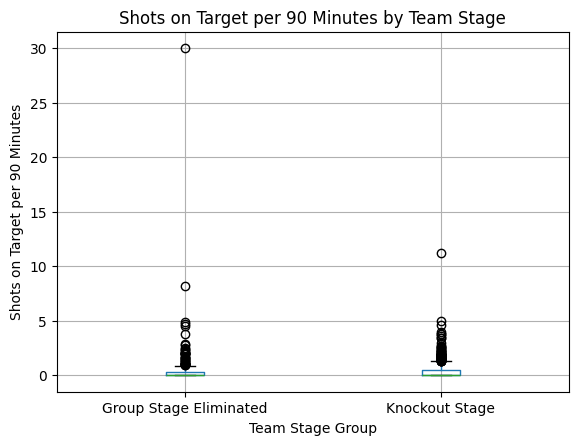

In [36]:
plt.figure(figsize=(9, 6))
df.boxplot(column="SoT/90", by="Analysis Group")
plt.title("Shots on Target per 90 Minutes by Team Stage")
plt.suptitle("")
plt.xlabel("Team Stage Group")
plt.ylabel("Shots on Target per 90 Minutes")
plt.xticks(rotation=0)
plt.show()

In [42]:
descriptive_stats = (df.groupby("Analysis Group")["SoT/90"].agg(count="count", mean="mean",
        median="median", std="std", minimum="min", maximum="max").round(2))

print("\nDescriptive Statistics:")
display(descriptive_stats)


Descriptive Statistics:


,count,mean,median,std,minimum,maximum
Analysis Group,,,,,,
Group Stage Eliminated,326,0.43,0.0,1.84,0.0,30.00
Knockout Stage,713,0.40,0.0,0.80,0.0,11.25


#### 95% Confidence Interval

In [46]:
ci_results = []
for group in ["Knockout Stage", "Group Stage Eliminated"]:
    values = df.loc[df["Analysis Group"] == group, "SoT/90"]
    lower, upper = confidence_interval(values)
    ci_results.append({"Analysis Group": group,"n": len(values), "Mean SoT/90": values.mean(),
            "95% CI Lower": lower, "95% CI Upper": upper})

ci_df = pd.DataFrame(ci_results)
print("\n95% Confidence Intervals:")
pd.DataFrame(ci_results).round(2)


95% Confidence Intervals:


,Analysis Group,n,Mean SoT/90,95% CI Lower,95% CI Upper
0,Knockout Stage,713,0.40,0.35,0.46
1,Group Stage Eliminated,326,0.43,0.23,0.63


The estimated mean for the group-stage-eliminated players (0.43) is slightly higher than that of the knockout-stage players (0.40).

The confidence intervals overlap substantially. This suggests that there is considerable uncertainty around the estimated mean for players from teams eliminated in the group stage.
Therefore, the confidence intervals do not provide clear evidence that knockout-stage players have a higher average number of shots on target per 90 minutes.

#### T-test


Null Hypothesis (H0): There is no difference in the average number of shots on target per 90 minutes between players from knockout-stage teams and players from teams eliminated in the group stage.

Alternative Hypothesis (H1): Players from teams that reached the knockout stage have a higher average number of shots on target per 90 minutes than players from teams eliminated in the group stage.

Significance level α = 0.05

In [48]:
knockout = df.loc[df["Analysis Group"] == "Knockout Stage","SoT/90"]
group_stage = df.loc[df["Analysis Group"] == "Group Stage Eliminated","SoT/90"]

In [50]:
t_statistic, p_value = ttest_ind(knockout, group_stage, equal_var=False, alternative="greater")
print(f"Knockout Stage mean: {knockout.mean():.3f}")
print(f"Group Stage Eliminated mean: {group_stage.mean():.3f}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.4f}")


Knockout Stage mean: 0.405
Group Stage Eliminated mean: 0.428
t-statistic: -0.2157
p-value: 0.5853


Fail to reject the null hypothesis.

There is insufficient statistical evidence to conclude that players from teams that reached the knockout stage have a significantly higher average number of shots on target per 90 minutes than players from teams eliminated in the group stage.